In [530]:
import numpy as np
import matplotlib.pyplot as plt

In [531]:
# Definerer klassen for spillere
class player:
    def __init__(self, power: int):
        self.elo = 1500
        self.power = power if power > 0 else 0
        self.name = f"playerWithPower {power}"
        self.numMatches = 0
        self.eloHistory = [self.elo]
        self.qualified = True

    def __str__(self):
        return f"{self.name:<20} Elo: {self.elo:<8} NumMatches: {self.numMatches:<12} Qualified: {self.qualified}"

    def completeMatch(self, newElo):
        self.numMatches += 1
        self.elo = newElo
        self.eloHistory.append(newElo)
        if (self.elo) < 1000:
            self.qualified = False

In [532]:
# Lager en liste med spillere
# Spillerne får gradvis høyere power, men det er litt randomisert
# Bedre spillere får større mulig intervall
def generatePlayers(numPlayers: int):
    players = []
    powers = []
    for i in range(0, numPlayers):
        power = np.random.randint(i**2, i**3 + 30)
        players.append(player(power))
        powers.append(power)

    plt.figure(figsize=(6, 3))
    plt.plot(powers, marker="o", linewidth=1)
    plt.grid()
    plt.show()

    players.sort(key=lambda p: p.power, reverse=True)

    return players

In [533]:
# Funksjon for å finne to konkurrenter
def findMatch(players: list[player]) -> player:
    if players is None:
        raise ValueError("players is None")
    matchNumbers = []
    for i in range(0, len(players)):
        p = players[i]
        if p.qualified:
            matchNumbers.append(p.numMatches)

    # Finn den femte laveste verdien i matchNumbers
    distinct = sorted(set(matchNumbers))
    if len(distinct) < 5:
        numMatchesEligible = distinct[-1]
    else:
        numMatchesEligible = distinct[4]

    playerPool = [
        p for p in players if ((p.numMatches <= numMatchesEligible) and p.qualified)
    ]
    p1Index = np.random.randint(0, len(playerPool))
    player1 = playerPool[p1Index]
    playerPool.remove(player1)
    player2 = playerPool[np.random.randint(0, len(playerPool))]

    return player1, player2

In [534]:
def match(player1: player, player2: player, f: int, K: int):
    R_1 = player1.elo
    R_2 = player2.elo
    dr = min(R_1 - R_2, 400)
    # dr = R_1 - R_2

    E_1 = 1 / (1 + 10 ** ((-dr) / f))
    E_2 = 1 / (1 + 10 ** ((dr) / f))

    # Finner ut hvem som vinner
    # Skalerer slik at spiller 1 har power1 / power_tot sjanse for å vinne
    power1 = player1.power
    power2 = player2.power

    p1wins = power1 / (power1 + power2)
    result = np.random.random()
    S_1 = int(result < p1wins)
    S_2 = int(result >= p1wins)

    R_1_new = R_1 + np.round(K * (S_1 - E_1))
    R_2_new = R_2 + np.round(K * (S_2 - E_2))

    player1.completeMatch(R_1_new)
    player2.completeMatch(R_2_new)

In [535]:
def disqualifyWorst(players: list[player], numPlayers: int):
    players.sort(key=lambda p: p.elo, reverse=True)
    players.sort(key=lambda p: p.qualified, reverse=False)

    for i in range(0, numPlayers):
        players[-(i + 1)].qualified = False


def getNumQualified(players: list[player]) -> int:
    return sum(1 for p in players if p.qualified)

In [536]:
def simulateTournament(players, f=400, K=32, totalNumMatches=1000, disqualify=False):
    for i in range(totalNumMatches):
        player1, player2 = findMatch(players)
        match(player1, player2, f, K)
        # Diskvalifiserer spillere underveis hvis det er ønskelig
        if disqualify:
            numQualifiedPlayers = getNumQualified(players)
            if numQualifiedPlayers > 16:
                if i % 1000 == 0 and i > 0:
                    # Diskvalifiserer de 2 dårligste ved x antall kamper
                    disqualifyWorst(players, 2)

    # return players
    plt.figure(figsize=(14, 8))
    playersToPlot = players
    for p in playersToPlot:
        plt.plot(p.eloHistory, linewidth="1", label=p.name)

    # plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [552]:
def plotEloBarchart(players: list[player]):
    sorted_players = sorted(players, key=lambda p: p.elo)  # ascending so top = highest
    names = [p.name for p in sorted_players]
    elos = [p.elo for p in sorted_players]

    fig, ax = plt.subplots(figsize=(12, len(players) * 0.4))
    bars = ax.barh(names, elos)
    # ax.bar_label(bars, labels=[str(e) for e in elos], padding=4)
    ax.bar_label(
        bars,
        labels=[f"elo: {p.elo}  |  {p.numMatches} matches" for p in sorted_players],
        padding=4,
    )
    ax.set_xlim((0, max(elos) * 1.4))
    ax.set_xlabel("Elo")
    ax.grid(axis="x")
    plt.tight_layout()
    plt.show()

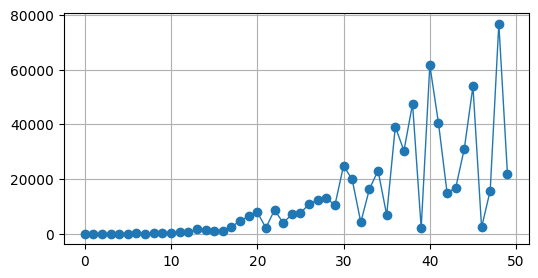

In [538]:
players = generatePlayers(50)

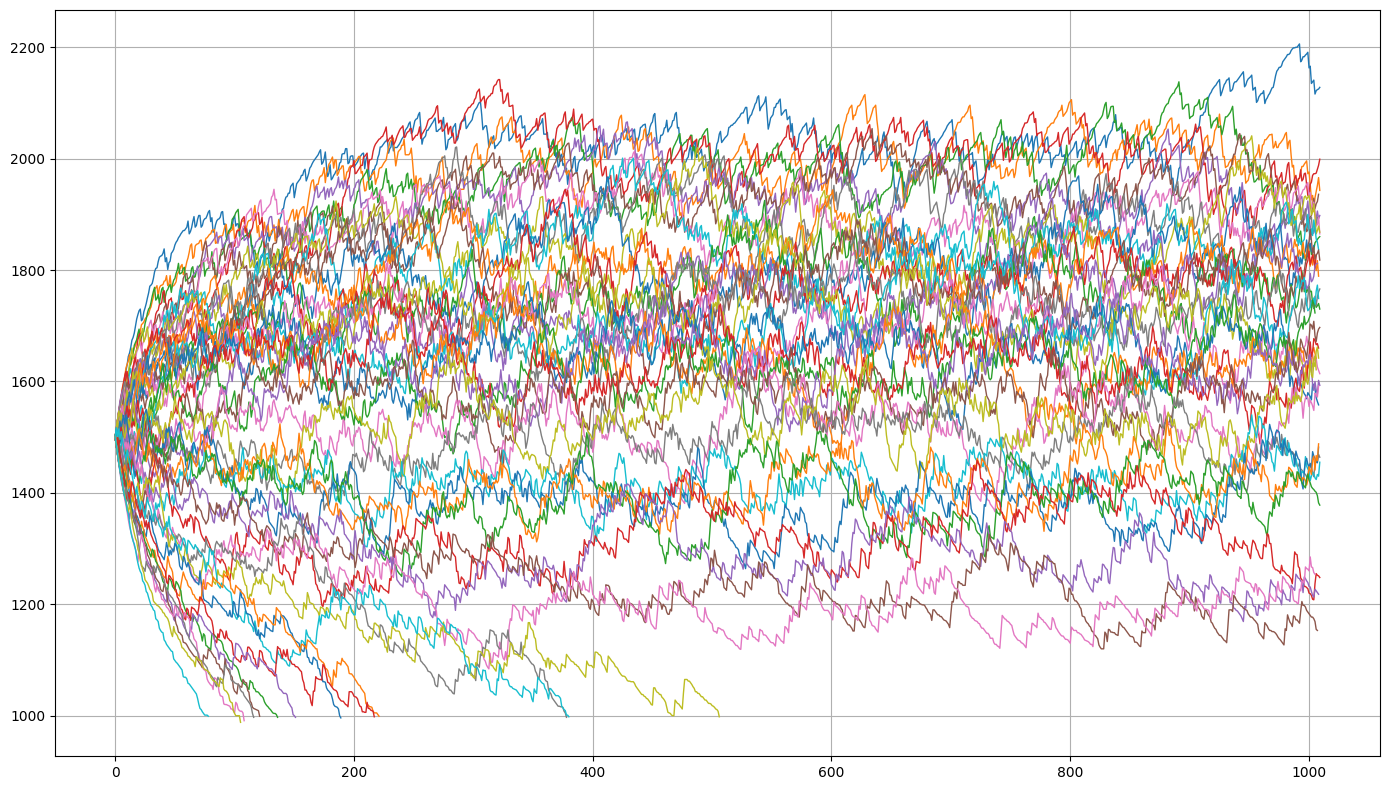

In [539]:
simulateTournament(players, f=400, K=32, totalNumMatches=20000, disqualify=False)

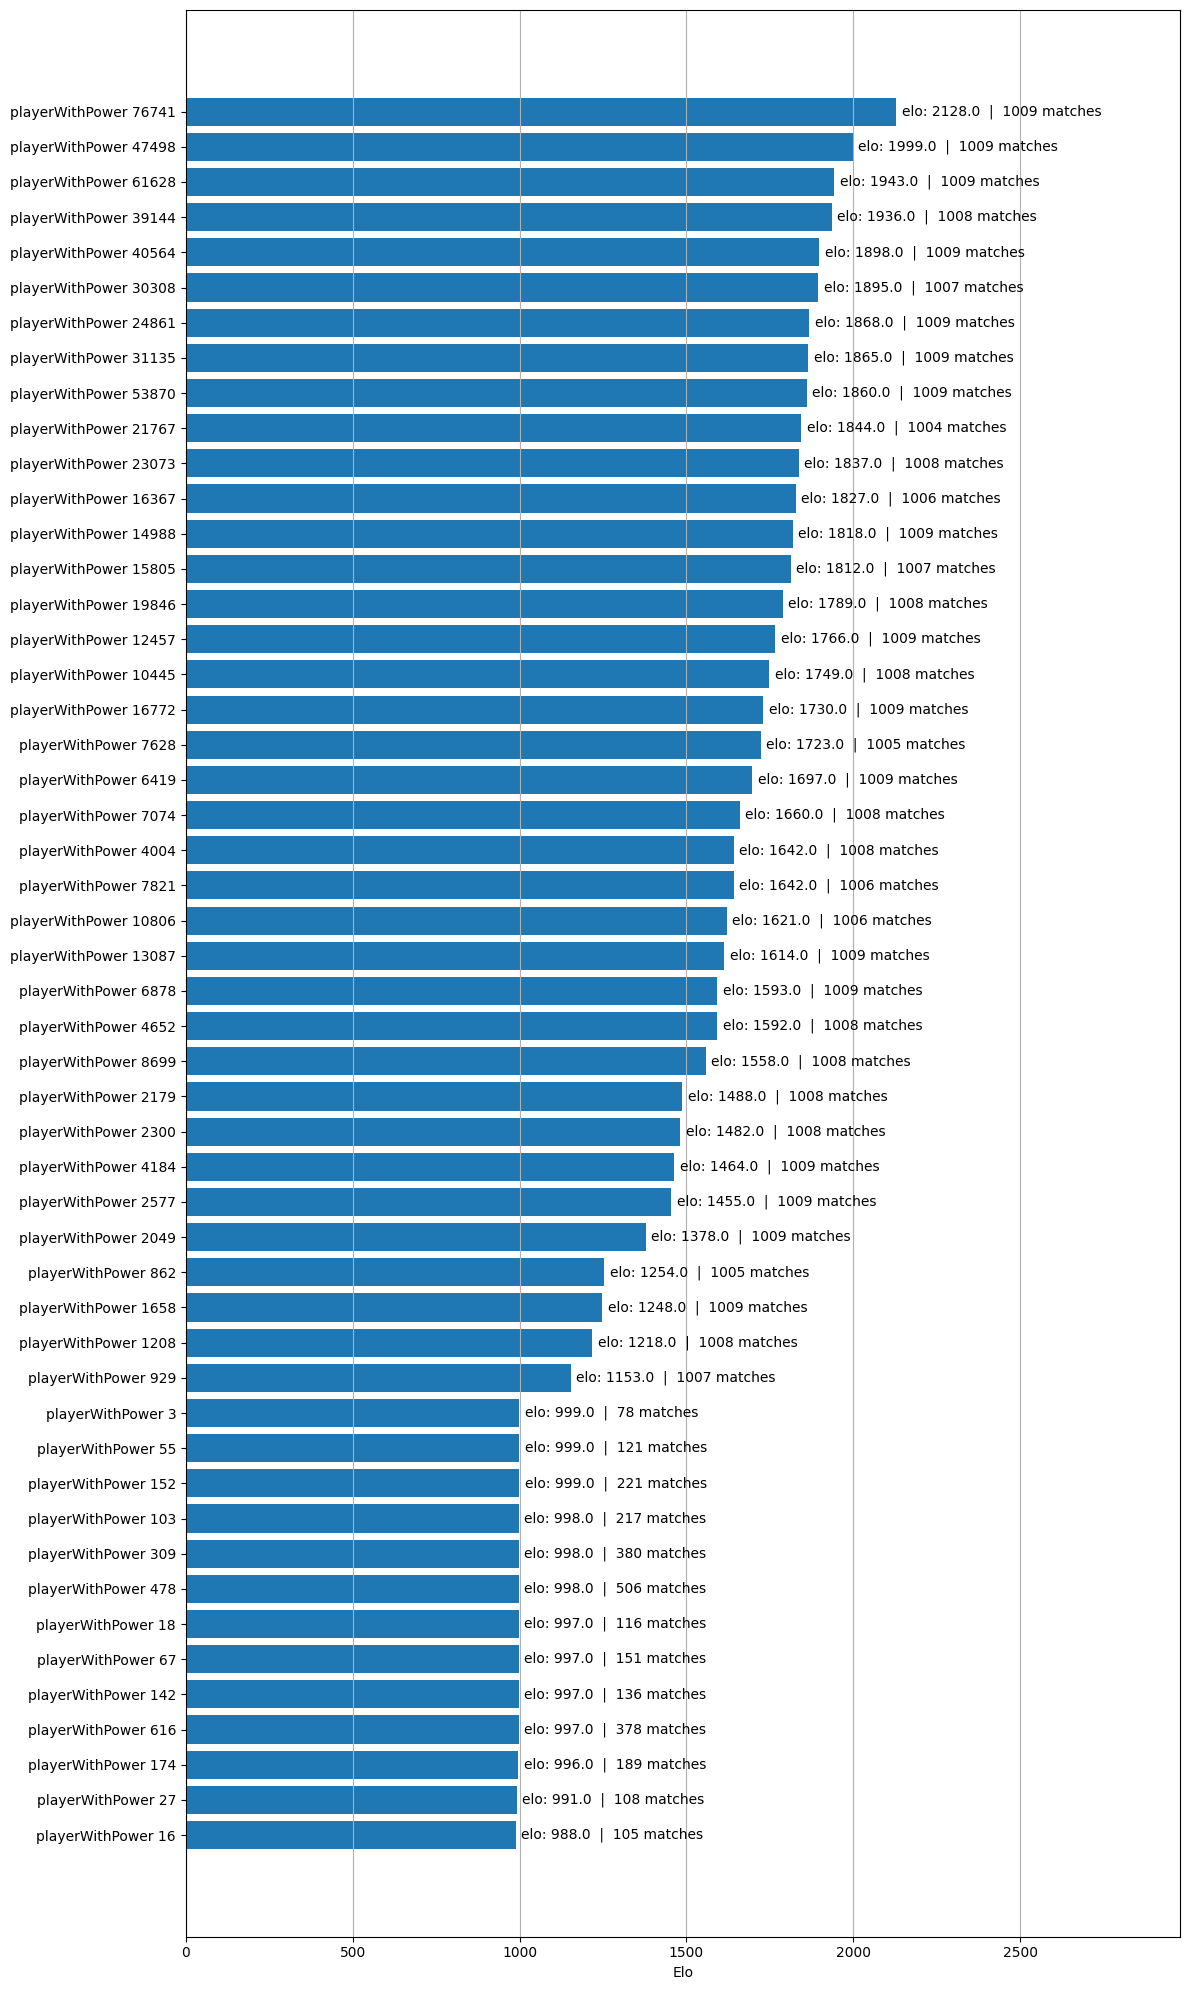

In [553]:
plotEloBarchart(players)